### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

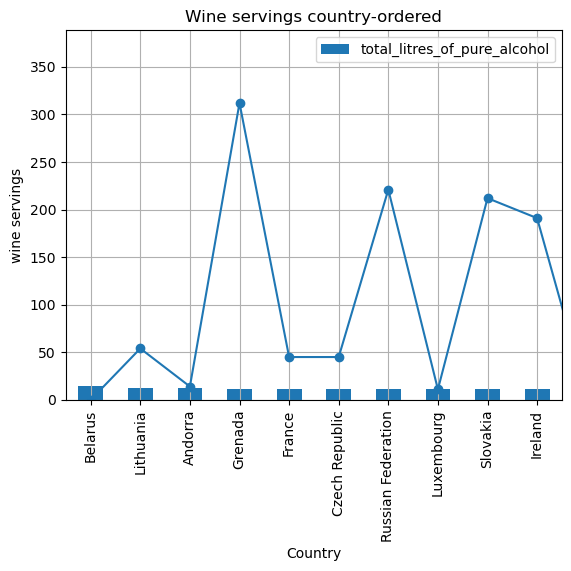

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
dfSorted = df.sort_values(by="total_litres_of_pure_alcohol", ascending=False)
top10_most_drinker = dfSorted[["country", "total_litres_of_pure_alcohol"]].head(10)

df[["beer_servings", "spirit_servings", "wine_servings"]].mean()

df["alcohol_index"] = (df["beer_servings"] + df["wine_servings"] + df["spirit_servings"]) / 3

maxIndex = df["alcohol_index"].max()
df[["country", "alcohol_index"]][df["alcohol_index"] == maxIndex]

df[["country", "beer_servings"]][df["beer_servings"]>100]

top10_most_drinker.plot.bar(x="country", y="total_litres_of_pure_alcohol")

plt.title('Country')
plt.ylabel('Ltr of alcohol')
#plt.show()

wine_servings_ordered = df.sort_values(by="country", ascending=True)[["country", "wine_servings"]]
wine_servings_ordered

plt.plot(wine_servings_ordered["country"], wine_servings_ordered["wine_servings"], marker='o')
plt.title("Wine servings country-ordered")
plt.xlabel("Country")
plt.ylabel("wine servings")
plt.grid(True)
plt.show()

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

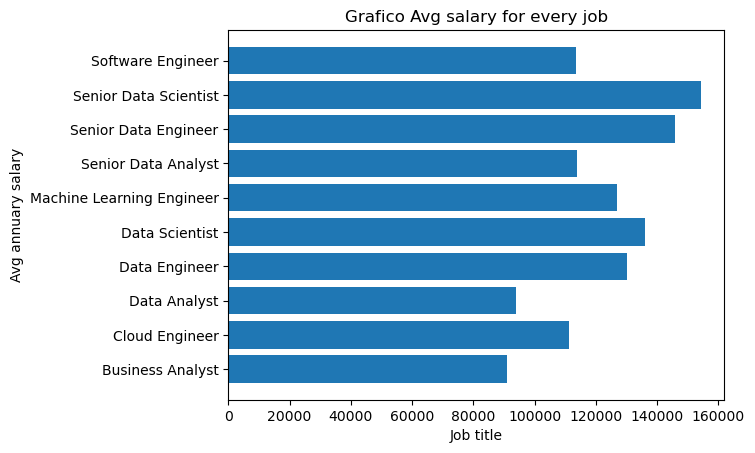

In [8]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

#df[df['salary_year_avg'].notna()].groupby('job_country')['salary_year_avg'].mean()
df.groupby('job_country')['salary_year_avg'].mean()

df.groupby('job_country')['job_country'].count()

df.groupby('job_country')['salary_year_avg'].agg(['min', 'max']).dropna()

grouped = df.groupby('job_title_short')['salary_year_avg'].mean()

plt.barh(grouped.index, grouped.values)

plt.xlabel('Job title')
plt.ylabel('Avg annuary salary')
plt.title('Grafico Avg salary for every job')

plt.show()

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

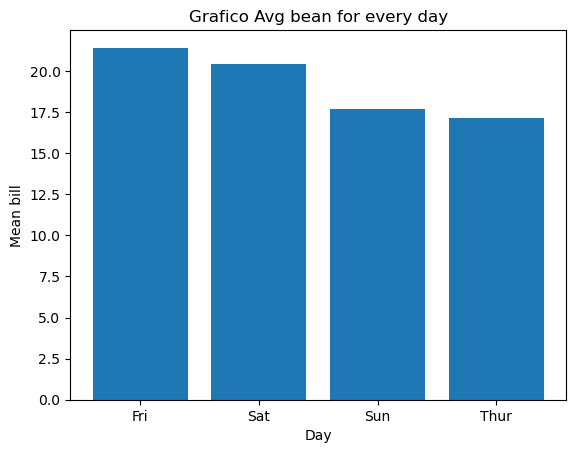

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

bill_mean = df.groupby('day')['total_bill'].mean()

df.value_counts('day')

df['total_bill'].min()
df['total_bill'].max()

df['conto_per_persona'] = df['total_bill'] / df['size']

bill_mean[bill_mean.values==bill_mean.max()]

bill_mean.sort_values(ascending=False)

plt.bar(bill_mean.index, (bill_mean.sort_values(ascending=False).values))
plt.xlabel('Day')
plt.ylabel('Mean bill')
plt.title('Grafico Avg bean for every day')
plt.show()